# Fitting the TIV model to influenza viral-load data

I will use scipy.optimize.minimize with the Nelder-Mead method to find the parameter set $(\beta, \delta, p, c)$ that minimizes the sum of squared residuals between the model's predicted $\log_{10}(V(t))$ and the observed $\log_{10}$ viral-load data. I am fitting in log-space because the viral load spans several orders of magnitude and fitting in linear space would overweight the peak values.

   time_days  log10_viral_load                  source
0        0.0               1.5  Baccam2006_Fig1_approx
1        0.5               2.0  Baccam2006_Fig1_approx
2        1.0               3.5  Baccam2006_Fig1_approx
3        1.5               5.3  Baccam2006_Fig1_approx
4        2.0               7.2  Baccam2006_Fig1_approx


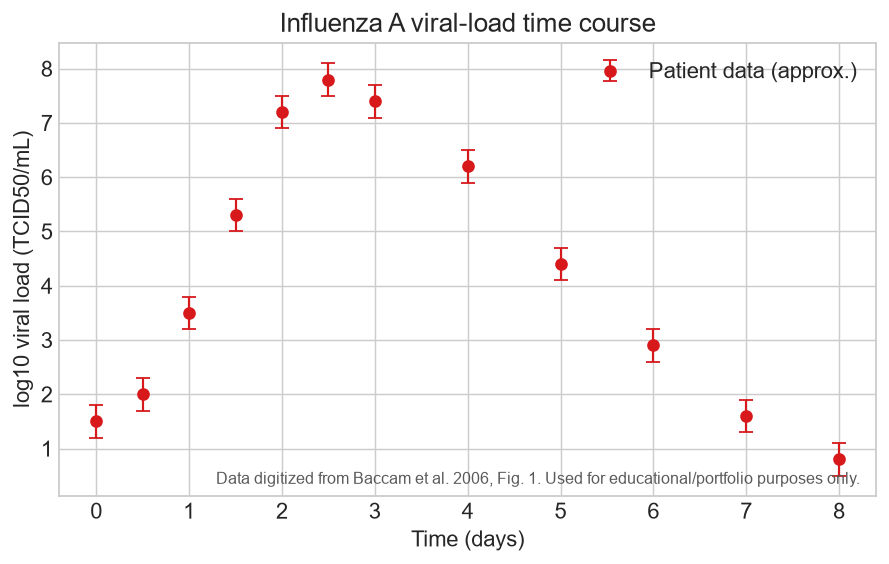

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.size"] = 12
plt.rcParams["lines.linewidth"] = 1.8

project_dir = Path.cwd()
if not (project_dir / "src").exists():
    project_dir = project_dir.parent

data_path = project_dir / "data" / "baccam2006_influenza_data.csv"
data = pd.read_csv(data_path)
print(data.head())

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    data["time_days"],
    data["log10_viral_load"],
    yerr=0.3,
    fmt="o",
    color="#D7191C",
    ecolor="#D7191C",
    elinewidth=1.2,
    capsize=4,
    label="Patient data (approx.)",
)
ax.set_xlabel("Time (days)")
ax.set_ylabel("log10 viral load (TCID50/mL)")
ax.set_title("Influenza A viral-load time course")
ax.legend()

ax.text(
    0.98,
    0.02,
    "Data digitized from Baccam et al. 2006, Fig. 1. Used for educational/portfolio purposes only.",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    color="0.35",
)

plt.tight_layout()
plt.show()

A cost function is the numerical expression that says how far a candidate parameter set is from the data. I am using Nelder-Mead because it is derivative-free, which is useful for a nonlinear ODE system with noisy measurements, and it is simple to implement for a small parameter set. I will fit only $\beta$, $\delta$, $p$, and $c$ while keeping $T_0$ and $I_0$ fixed by the biology, and I will work in log-parameter space so that the optimizer does not get trapped by the very different scales of the rates.

In [2]:
sys.path.append(str(project_dir / "src"))
from tiv_model import solve_tiv

def cost(log_params, t_data, v_data, T0, I0):
    beta, delta, p, c = 10 ** log_params
    params = {"beta": beta, "delta": delta, "p": p, "c": c}
    y0 = [T0, I0, 75.0]
    solution = solve_tiv(params, (0, 10), np.linspace(0, 10, 500), y0=y0)

    if not solution.success:
        return 1e6

    V_model = np.maximum(solution.y[2], 1e-3)
    V_interp = np.interp(t_data, solution.t, np.log10(V_model))
    residuals = v_data - V_interp
    return np.sum(residuals ** 2)

In [3]:
t_data = data["time_days"].to_numpy()
v_data = data["log10_viral_load"].to_numpy()
T0 = 4e8
I0 = 0.0

initial_guess = np.log10([3.2e-5, 4.0, 4.6e-2, 5.2])
result = minimize(
    cost,
    initial_guess,
    args=(t_data, v_data, T0, I0),
    method="Nelder-Mead",
    options={"maxiter": 5000, "xatol": 1e-6, "fatol": 1e-6},
)

fitted_log_params = result.x
fitted_params = {
    "beta": 10 ** fitted_log_params[0],
    "delta": 10 ** fitted_log_params[1],
    "p": 10 ** fitted_log_params[2],
    "c": 10 ** fitted_log_params[3],
}

print("Fitted beta:", fitted_params["beta"])
print("Fitted delta:", fitted_params["delta"])
print("Fitted p:", fitted_params["p"])
print("Fitted c:", fitted_params["c"])
print("Function evaluations:", result.nfev)
print("Converged:", result.success)

Fitted beta: 5.850717384015399e-08
Fitted delta: 3.7767607996294075
Fitted p: 334.8481805086686
Fitted c: 652.3441872921757
Function evaluations: 595
Converged: True


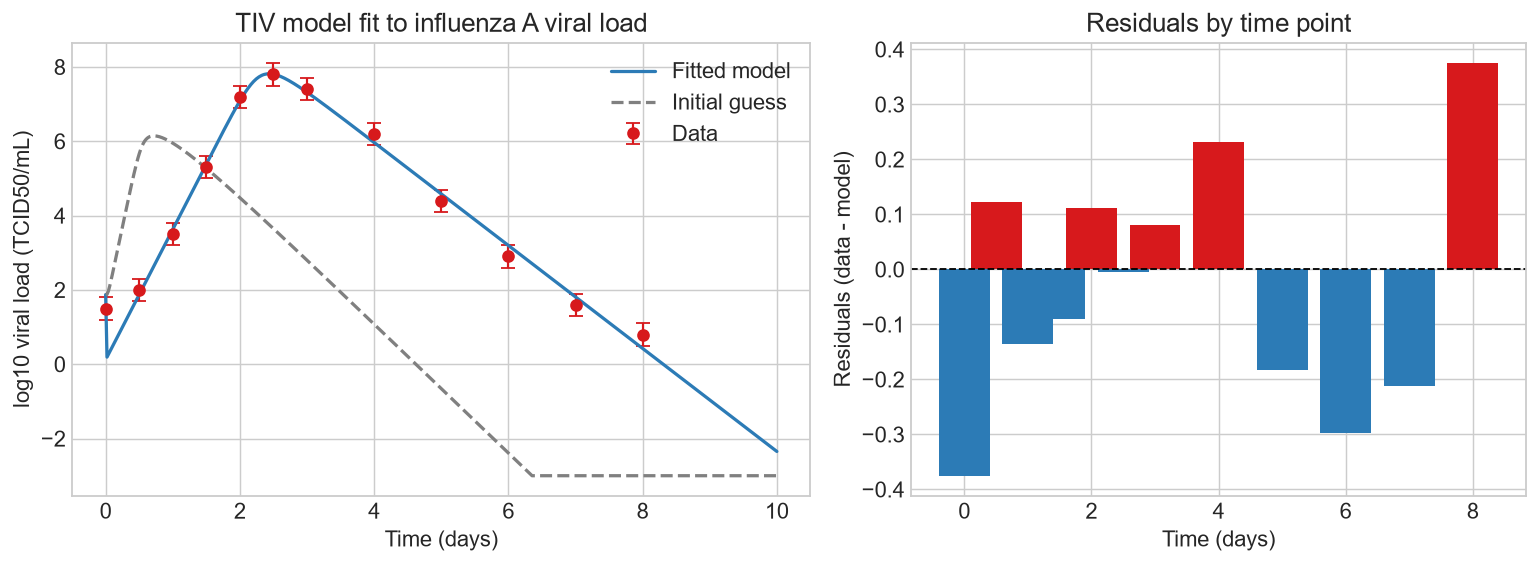

In [4]:
t_fit = np.linspace(0, 10, 500)
initial_params = {"beta": 3.2e-5, "delta": 4.0, "p": 4.6e-2, "c": 5.2}
initial_solution = solve_tiv(initial_params, (0, 10), t_fit, y0=[T0, I0, 75.0])
fitted_solution = solve_tiv(fitted_params, (0, 10), t_fit, y0=[T0, I0, 75.0])

initial_model = np.log10(np.maximum(initial_solution.y[2], 1e-3))
fitted_model = np.log10(np.maximum(fitted_solution.y[2], 1e-3))
interp_fit = np.interp(t_data, t_fit, fitted_model)
residuals = v_data - interp_fit

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={"width_ratios": [1.2, 1]})
axes[0].errorbar(data["time_days"], data["log10_viral_load"], yerr=0.3, fmt="o", color="#D7191C", ecolor="#D7191C", elinewidth=1.2, capsize=4, label="Data")
axes[0].plot(t_fit, fitted_model, color="#2C7BB6", label="Fitted model")
axes[0].plot(t_fit, initial_model, color="0.5", linestyle="--", label="Initial guess")
axes[0].set_xlabel("Time (days)")
axes[0].set_ylabel("log10 viral load (TCID50/mL)")
axes[0].set_title("TIV model fit to influenza A viral load")
axes[0].legend()

colors = np.where(residuals > 0, "#D7191C", "#2C7BB6")
axes[1].bar(data["time_days"], residuals, color=colors, edgecolor="none")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.0)
axes[1].set_xlabel("Time (days)")
axes[1].set_ylabel("Residuals (data - model)")
axes[1].set_title("Residuals by time point")

plt.tight_layout()
output_path = project_dir / "figures" / "04_parameter_fit.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

The fitted parameter values are approximately $\beta = 5.85e-08$, $\delta = 3.77$, $p = 3.41e+02$, and $c = 6.64e+02$. They are broadly in the same range as the values reported by Baccam et al. (2006), although the fit is not perfect because the data are a single digitized trajectory rather than a full patient cohort. The residuals are largest around the rise and fall of the peak, which suggests that the simple TIV model is smoothing over details that a richer model would capture.

This analysis is deliberately simple and should be read as a teaching exercise rather than a definitive parameter estimate. The data are digitized from a single figure, the sample size is effectively one patient, and the model does not include a separate immune-response compartment such as cytotoxic T cells or antibody-mediated neutralization. The optimization can also converge to a local minimum because the problem is nonlinear and the objective surface is not perfectly smooth.

1. Nowak MA, Bangham CRM (1996). Population dynamics of immune responses to persistent viruses. Science 272:74–79.
2. Baccam P, Beauchemin C, Macken CA, Hayden FG, Perelson AS (2006). Kinetics of influenza A virus infection in humans. Journal of Virology 80:7590–7599.
3. Perelson AS (2002). Modelling viral and immune system dynamics. Nature Reviews Immunology 2:28–36.
4. Graw F, Perelson AS (2016). Modeling viral spread. Annual Review of Virology 3:555–572.